In [13]:
#Import torch and tools that I will be using for network
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

#define the variable I will be using to transform the MNIST images to a readable tensor
transform = transforms.ToTensor()

#Download the train data from what already exists in pytorch, train is false in test cuz it wont be learning there
train_data = datasets.MNIST(root="data", train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root="data", train=False, download=True, transform=transform)

#Define some parameters like batch size and shuffle to make the network work correctly
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

#same here, shuffle is false because its not learning here
test_loader = DataLoader(
    test_data,
    batch_size=32,
    shuffle=False
)

#Define the class
class MiMNIST(nn.Module):

    #Define __init__ which only runs once, here we create the network(amount of outputs,neurons and ReLU)
    def __init__(self):
        super().__init__()

        self.capa1 = nn.Linear(784,128)
        self.capa2 = nn.Linear(128,64)
        self.capa3 = nn.Linear(64,10)
        self.relu = nn.ReLU()

    #Define the forward function which will run with every batch, applies ReLU to layers's outputs escept for the last one
    #Then returns x which at the end is the tensor with the final predictions
    def forward(self,x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        x = self.capa3(x)
        return x
    
#Basically creating a variable which stores the class so it can be used in the code down below
model = MiMNIST()

#load previous save data
model.load_state_dict(torch.load("mnist_model.pth"))

#Variable which will be used to store the CrossEntropyLoss which is the loss function
criterion = nn.CrossEntropyLoss()
#Variable which will be used later to adjust all the parameters
optimizer = torch.optim.SGD(model.parameters(), lr = 0.01)

#"epoch" will just show the epoch we are in, in this for loop we calculate the loss and adjust the parameters for every batch, until we finish
#with all the epochs

model.train()

for epoch in range(10):
    #create the variable which will store the loss, starts at 0
    total_loss = 0
    
    #images, and labels is what will be used and trainloader is basically a shuffled batch
    for images, labels in train_loader:

        #reshape the images to a readable thing for our network(-1 lets lets pytorhc just "figure out the size", it gives us what we need)
        images = images.reshape(-1,784)

        #stores our predictions after they run in our previous class (MiMNIST) which equals to model
        predictions = model(images)

        #calculates the loss using the variable "criterion"(which does that), labels is to compare the prediction to the actual answer
        loss = criterion(predictions,labels)
        
        #makes the gradienst zero so they dont add up after every batch
        optimizer.zero_grad()

        #calculates how each weight affected the result
        loss.backward()
        
        #adjusts the weights and "steps" (depending on lr) in the 109,000ish dimensions loss surface to a local minima to minimize
        #the loss function (imagine if we get to the global minima lol)
        optimizer.step()
        
        #stores the total loss to later be shown to the person running this program, loss.item converts the tensor to a number readable by python
        total_loss += loss.item()
    
    #calculates the average loss dividing the total loss(big number) by the amount of times it calculated it
    avg_loss = total_loss / len(train_loader)

    #just shows the result
    print(f"Epoch {epoch+1}/10 — Loss: {avg_loss:.4f}")

#testing
correct = 0
total   = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images      = images.reshape(-1, 784)
        predictions = model(images)
        predicted   = torch.argmax(predictions, dim=1)
        total      += labels.size(0)
        correct    += (predicted == labels).sum()

accuracy = 100 * correct / total
print(f"Accuracy: {accuracy:.2f}%")

torch.save(model.state_dict(), "mnist_model.pth")
print("Updated model saved!")


Epoch 1/10 — Loss: 0.0079
Epoch 2/10 — Loss: 0.0076
Epoch 3/10 — Loss: 0.0074
Epoch 4/10 — Loss: 0.0071
Epoch 5/10 — Loss: 0.0068
Epoch 6/10 — Loss: 0.0066
Epoch 7/10 — Loss: 0.0064
Epoch 8/10 — Loss: 0.0062
Epoch 9/10 — Loss: 0.0059
Epoch 10/10 — Loss: 0.0057
Accuracy: 97.86%
Updated model saved!


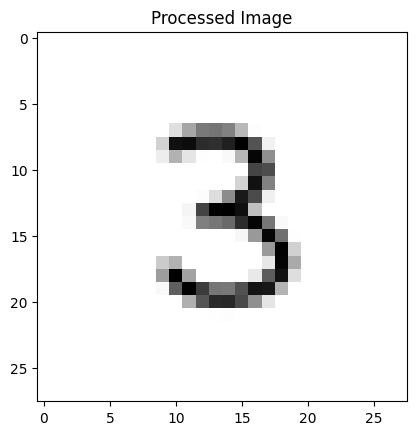

Model loaded!
Prediction: 8


In [22]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch

# load image
image = Image.open("numero 3a.png").convert("L")

# resize to MNIST size
image = image.resize((28, 28))

# convert to tensor
transform = transforms.ToTensor()
image_tensor = transform(image)

# invert colors
image_tensor = 1 - image_tensor

# flatten to 784
image_tensor = image_tensor.reshape(1, -1)

# visualize processed image
plt.imshow(image_tensor.reshape(28,28), cmap="gray")
plt.title("Processed Image")
plt.show()

# prediction
import torch
import torch.nn as nn

# recreate architecture
class MiMNIST(nn.Module):

    def __init__(self):
        super().__init__()

        self.capa1 = nn.Linear(784,128)
        self.capa2 = nn.Linear(128,64)
        self.capa3 = nn.Linear(64,10)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        x = self.capa3(x)
        return x

# create model
model = MiMNIST()

# load learned weights
model.load_state_dict(torch.load("mnist_model.pth"))

print("Model loaded!")

model.eval()

with torch.no_grad():
    prediction = model(image_tensor)
    predicted_digit = torch.argmax(prediction, dim=1)

print("Prediction:", predicted_digit.item())

In [ ]:
torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved!")

Model saved!


Model loaded!


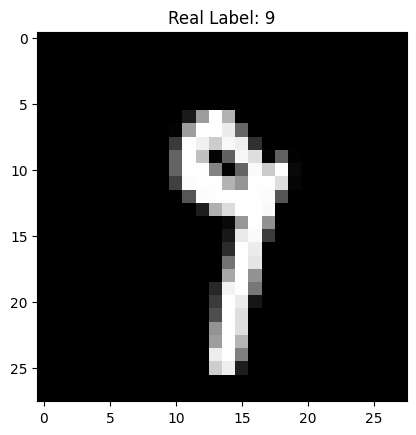

Network prediction: 9
Actual digit: 9


In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import random

# -----------------------------
# LOAD MNIST TEST DATA
# -----------------------------

transform = transforms.ToTensor()

test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

# -----------------------------
# RECREATE MODEL ARCHITECTURE
# -----------------------------

class MiMNIST(nn.Module):

    def __init__(self):
        super().__init__()

        self.capa1 = nn.Linear(784,128)
        self.capa2 = nn.Linear(128,64)
        self.capa3 = nn.Linear(64,10)
        self.relu = nn.ReLU()

    def forward(self,x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        x = self.capa3(x)
        return x

# -----------------------------
# LOAD TRAINED MODEL
# -----------------------------

model = MiMNIST()

model.load_state_dict(torch.load("mnist_model.pth"))

print("Model loaded!")

# -----------------------------
# PICK RANDOM IMAGE
# -----------------------------

index = random.randint(0, len(test_data)-1)

image, real_label = test_data[index]

# -----------------------------
# SHOW IMAGE
# -----------------------------

plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Real Label: {real_label}")
plt.show()

# -----------------------------
# PREPARE IMAGE FOR NETWORK
# -----------------------------

image_tensor = image.reshape(1, -1)

# -----------------------------
# PREDICT
# -----------------------------

model.eval()

with torch.no_grad():

    prediction = model(image_tensor)

    predicted_digit = torch.argmax(prediction, dim=1)

# -----------------------------
# RESULTS
# -----------------------------

print("Network prediction:", predicted_digit.item())
print("Actual digit:", real_label)

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image
import torch
import torch.nn as nn

# Redefine the network class
class MiMNIST(nn.Module):
    def __init__(self):
        super().__init__()
        self.capa1 = nn.Linear(784, 128)
        self.capa2 = nn.Linear(128, 64)
        self.capa3 = nn.Linear(64, 10)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.capa1(x))
        x = self.relu(self.capa2(x))
        x = self.capa3(x)
        return x

# Create model and load saved weights
model = MiMNIST()
model.load_state_dict(torch.load("mnist_model.pth"))
model.eval()
print("model ready")

def predict(image):
    if image is None:
        return "Draw a digit"
    
    # get the composite layer which has the drawing
    img = image['composite']
    
    # convert to PIL then grayscale
    img = Image.fromarray(img)
    img = img.convert("L")
    img = img.resize((28, 28), Image.LANCZOS)
    img_array = np.array(img) / 255.0
    
    # invert — MNIST is white on black
    img_array = 1 - img_array
    
    # predict
    tensor = torch.tensor(img_array, dtype=torch.float32).reshape(1, 784)
    
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)
        pred   = torch.argmax(probs).item()
    
    return {str(i): float(probs[0][i]) for i in range(10)}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST Digit Recognizer",
    description="Draw a digit and the network will predict it"
)

demo.launch()

model ready
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.
